# Task 1: Exploring and Visualizing the Iris Dataset

Objective: Load, inspect, and visualize the Iris dataset to understand data trends and distributions.

In [1]:
# Install/import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 1: Load the Dataset

In [2]:
# Load the Iris dataset using seaborn's built-in loader
df = sns.load_dataset('iris')

print('Dataset loaded!')
print(f'Shape: {df.shape}')
print(f'Column names: {list(df.columns)}')

Dataset loaded!
Shape: (150, 5)
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


## Step 2: Inspect the Data

In [3]:
# First few rows
print('First 5 rows:')
df.head()

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Data types and non-null counts
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Summary statistics
print('Descriptive Statistics:')
df.describe()

Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Check class distribution
print('Species distribution:')
print(df['species'].value_counts())

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Step 3: Visualizations

### 3a. Scatter Plot — Feature Relationships

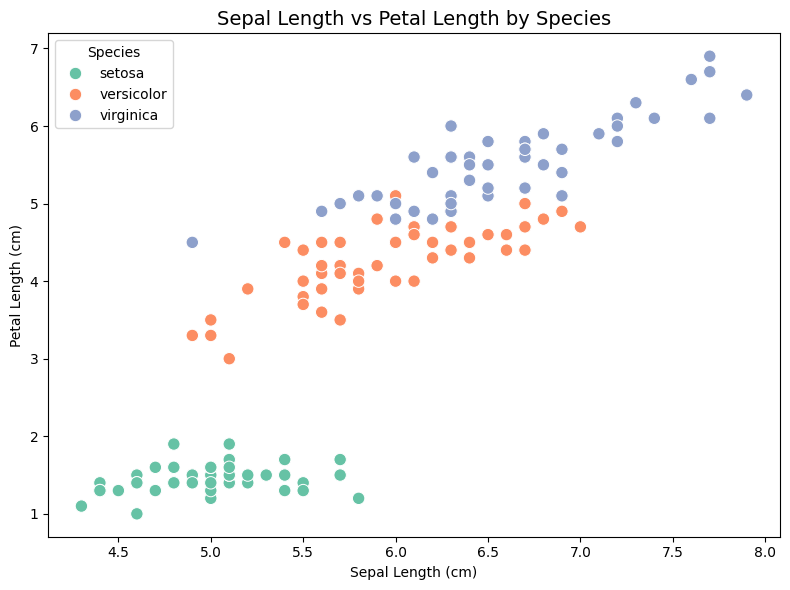

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='petal_length',
    hue='species',
    palette='Set2',
    s=80
)
plt.title('Sepal Length vs Petal Length by Species', fontsize=14)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

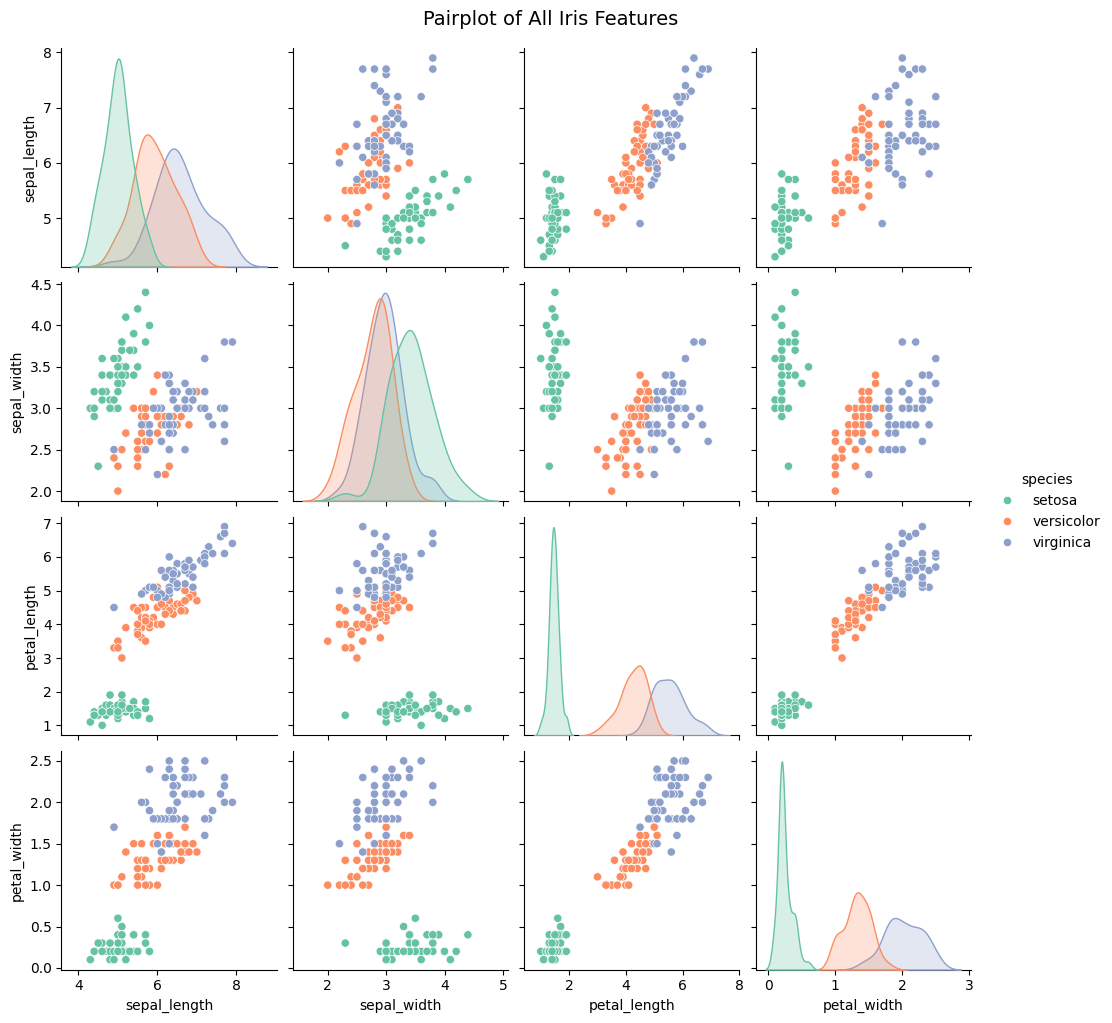

In [8]:
# Pairplot to see all feature combinations at once
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot of All Iris Features', y=1.02, fontsize=14)
plt.show()

### 3b. Histograms — Value Distributions

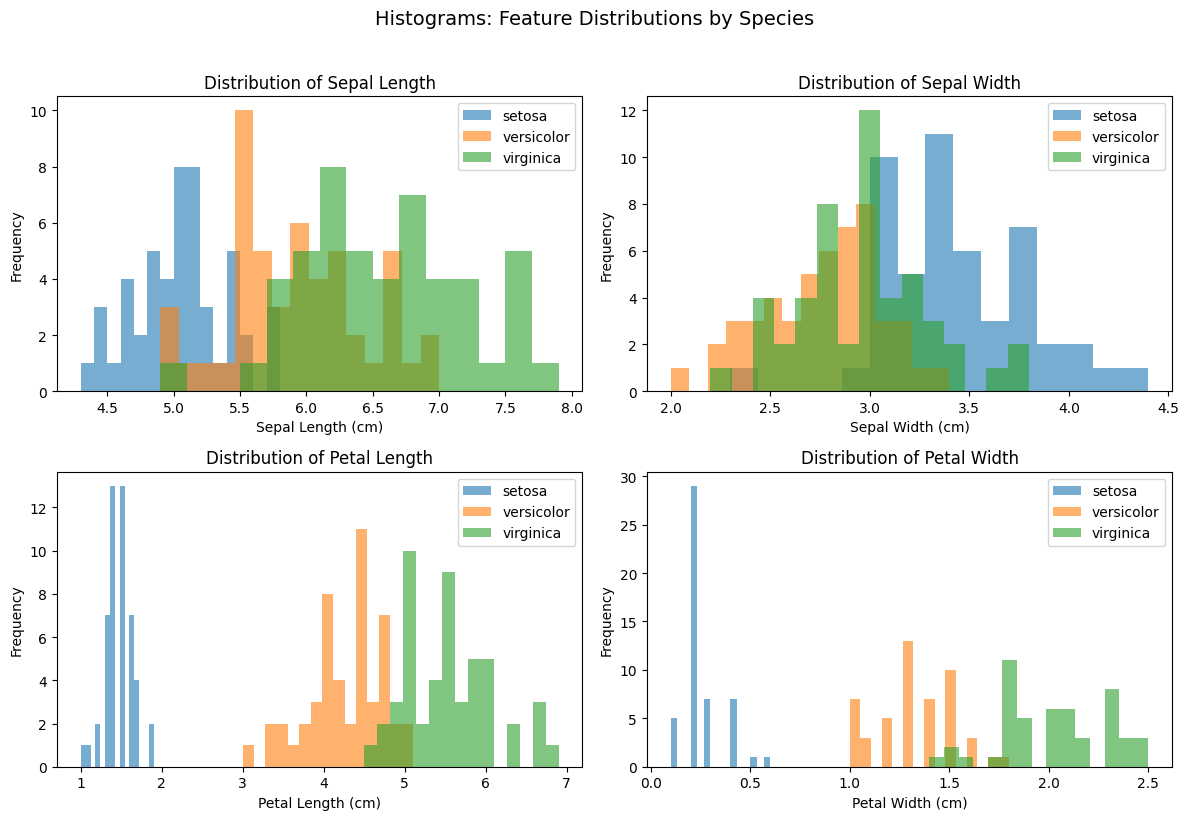

In [9]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        ax.hist(subset, bins=15, alpha=0.6, label=species)
    ax.set_title(f'Distribution of {feature.replace("_", " ").title()}')
    ax.set_xlabel(feature.replace('_', ' ').title() + ' (cm)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Histograms: Feature Distributions by Species', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3c. Box Plots — Outlier Detection

/tmp/ipykernel_3687/450960553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3687/450960553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3687/450960553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3687/450960553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


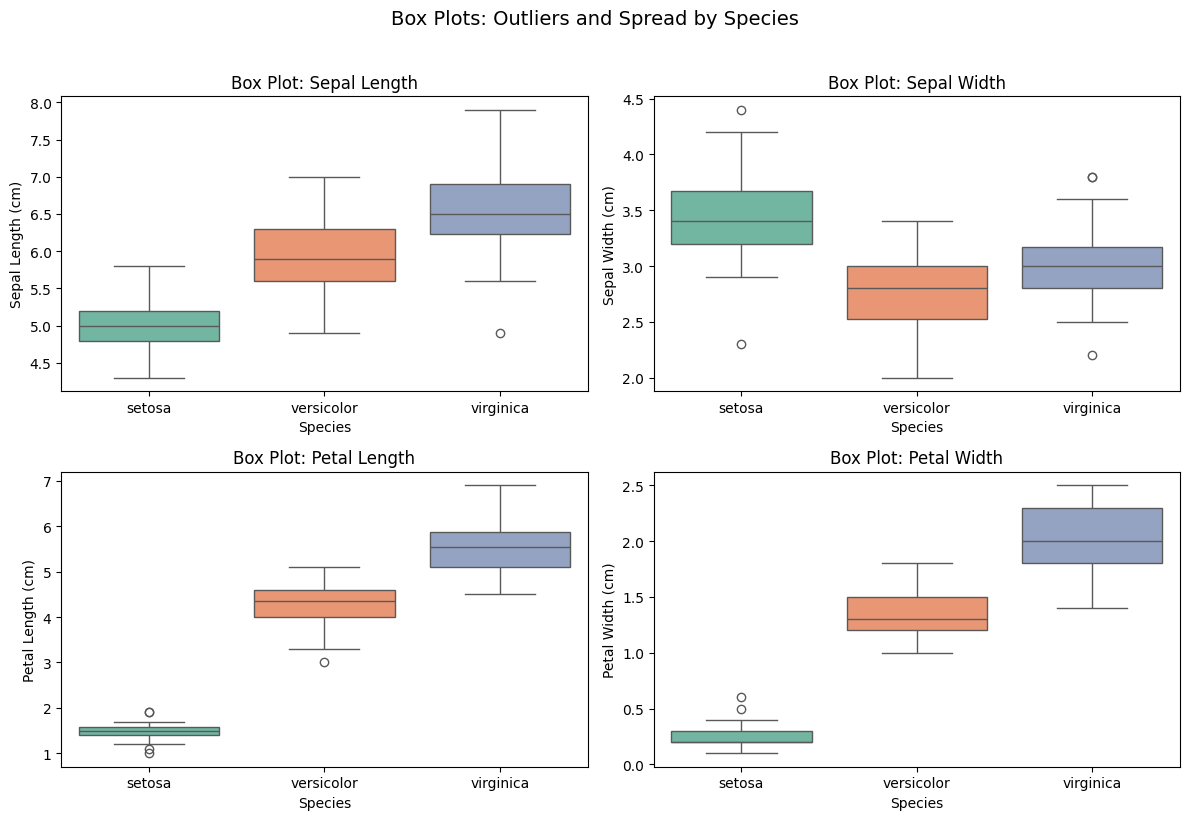

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x='species',
        y=feature,
        palette='Set2',
        ax=ax
    )
    ax.set_title(f'Box Plot: {feature.replace("_", " ").title()}')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature.replace('_', ' ').title() + ' (cm)')

plt.suptitle('Box Plots: Outliers and Spread by Species', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3d. Correlation Heatmap

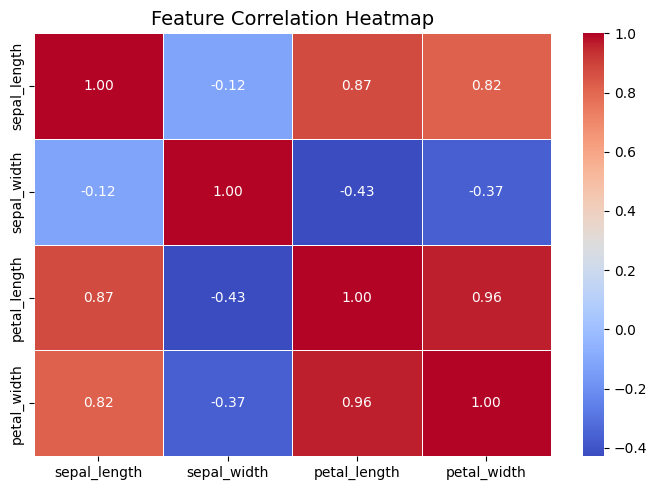

In [12]:
plt.figure(figsize=(7, 5))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
print('\nKey Insight: Petal length and petal width are highly correlated (>0.96)!')


Key Insight: Petal length and petal width are highly correlated (>0.96)!
